# Plot: Uncertainty Boxplot by Week (Model I)
Extracted from task1/scripts/run_uncertainty_boxplot.py


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

PAPER_RC = {
    # Font sizes
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,
    "figure.titlesize": 12,

    # Figure settings
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.figsize": (6.5, 3.5),

    # Style
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.axisbelow": True,

    # Font family
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
}

def apply_paper_style():
    """Apply paper-ready matplotlib style."""
    plt.rcParams.update(PAPER_RC)

apply_paper_style()


In [2]:
# =========================
# 1) 路径与配置
# =========================
# 默认从 notebooks/26Feb2-mcm 目录运行
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
DATA_DIR = os.path.join(BASE_DIR, "data", "26Feb2-mcm")
FIGDIR = os.path.join(BASE_DIR, "figures", "26Feb2-mcm")

# LaTeX single-column figure sizes
FIGSIZE_STANDARD = (6.5, 3.5)
FIGSIZE_WIDE = (6.5, 2.8)
FIGSIZE_TALL = (6.5, 4.5)
FIGSIZE_DUAL = (8.6, 3.2)
DPI = 300

FIGSIZE = FIGSIZE_STANDARD

DATA_CSV = os.path.join(DATA_DIR, "03_uncertainty_by_week", "uncertainty_summary_by_person_week.csv")
OUT_PDF = os.path.join(FIGDIR, "task2-uncertainty_boxplot_by_week.pdf")

os.makedirs(FIGDIR, exist_ok=True)


In [3]:
# Paper style settings

def plot_uncertainty_by_week(data_path: str, output_path: str):
    """Generate uncertainty boxplot by week."""
    summary = pd.read_csv(data_path)

    week_order = sorted(summary["week"].unique().tolist())
    data_by_week = [
        summary.loc[summary["week"] == w, "V_iqr"].dropna().to_numpy()
        for w in week_order
    ]

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.boxplot(data_by_week, tick_labels=[str(w) for w in week_order], showfliers=False)
    ax.set_xlabel("Week")
    ax.set_ylabel("Uncertainty (IQR of V_hat)")
    fig.suptitle("Model I: Uncertainty by Week", x=0.52, y=0.97, ha="center", fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.savefig(output_path, dpi=DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_path}")


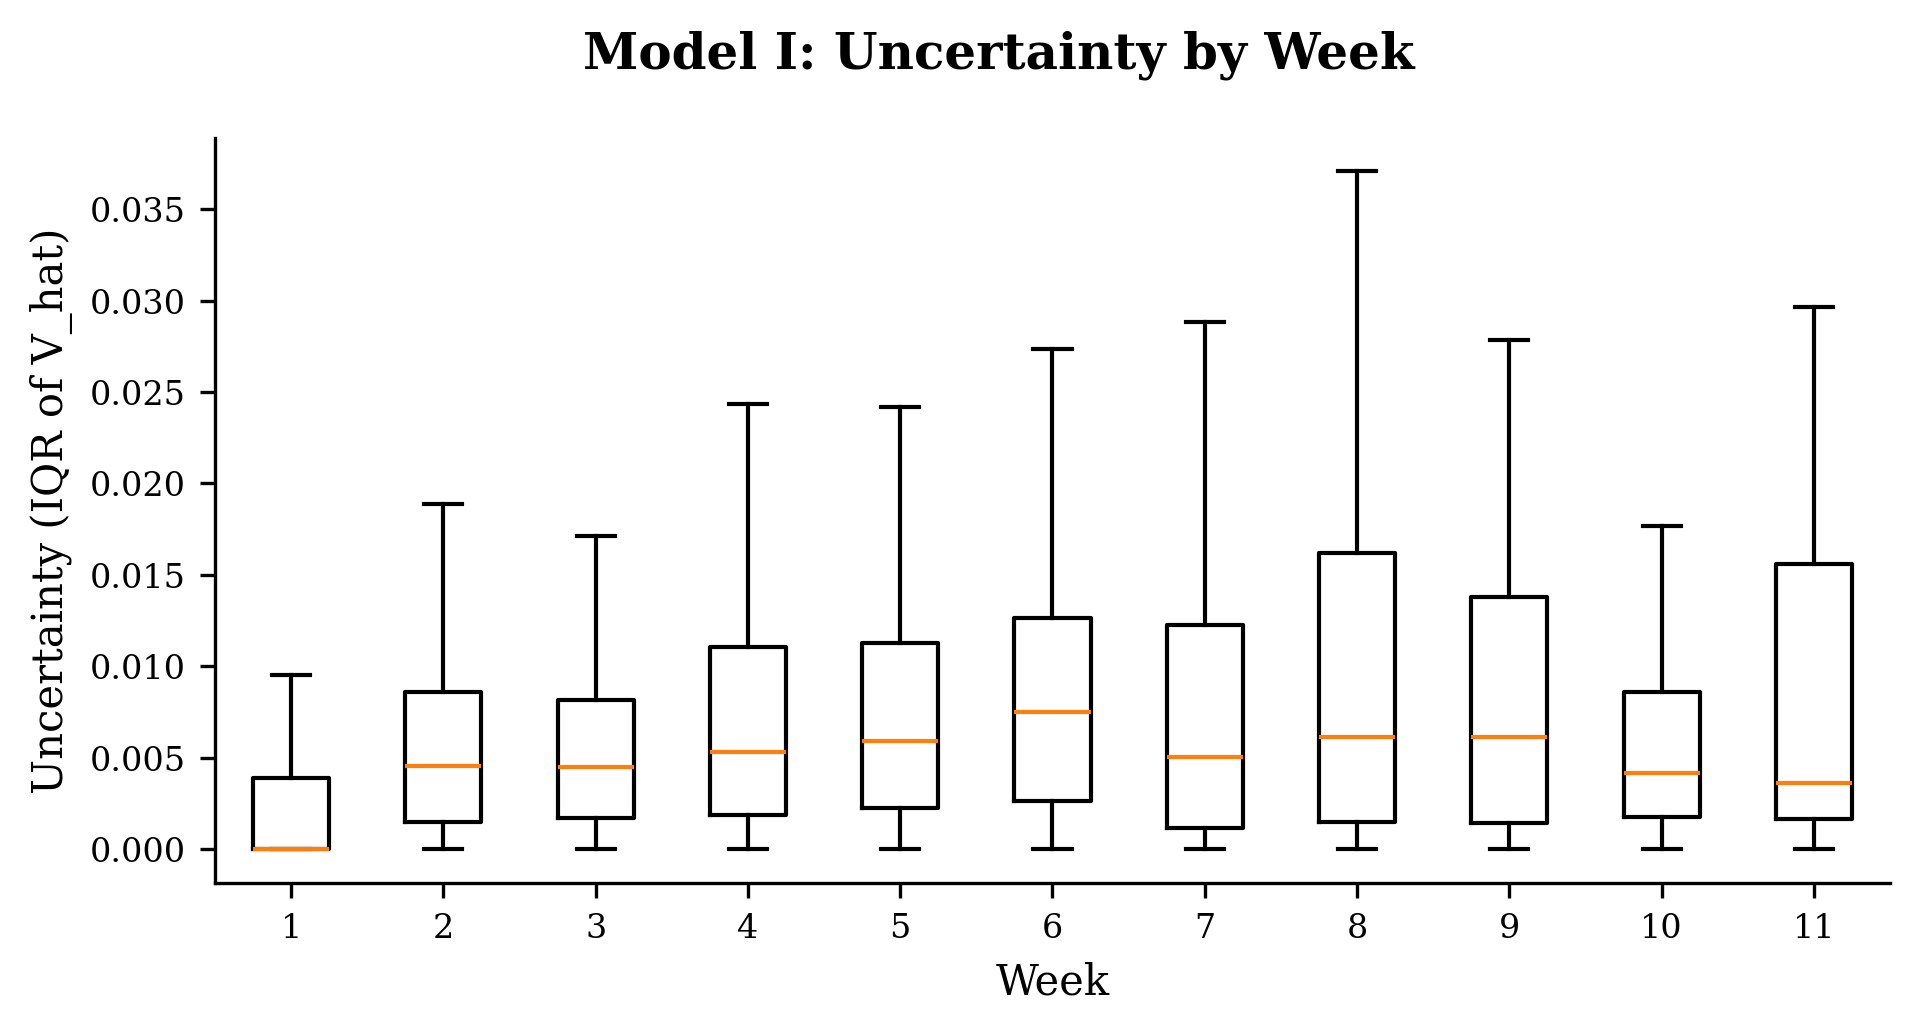

Saved: /home/winbeau/Tools/jupyter-plot/figures/26Feb2-mcm/task2-uncertainty_boxplot_by_week.pdf
Saved: /home/winbeau/Tools/jupyter-plot/figures/26Feb2-mcm/task2-uncertainty_boxplot_by_week.pdf


In [4]:
plot_uncertainty_by_week(DATA_CSV, OUT_PDF)
print("Saved:", OUT_PDF)
